In [1]:
from statsmodels.genmod.families.links import *
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cskpd_new_update import *
from oasis_helpers import plot_model

with open('oasis_3d.pkl', 'rb') as f:
    X, Z, Y = pickle.load(f).values()

Y = np.array([y if y is not None else 0 for y in Y])
idx = np.where(np.array([y is not None for y in Y]))
X = np.array(X)[idx]
Z = np.array(Z)[idx]
Y = np.array([1 if x else 0 for x in np.array(Y)[idx] >= 0.5])

In [2]:
import numpy as np
import pandas as pd
import cv2

def resize_image(image, new_height, new_width):
    # Mask of non-zeros
    # initiate as 96x96
    # image = cv2.bilateralFilter(image,9,75,75)
    image = np.array(image)
    original_height, original_width = image.shape
    mask = image != 0  # Use a >tolerance for a tolerance defining black border

    # Mask of non-zero rows and columns
    mask_row = mask.any(1)
    mask_col = mask.any(0)

    # First, last indices among the non-zero rows
    sr0, sr1 = mask_row.argmax(), len(mask_row) - mask_row[::-1].argmax()

    # First, last indices among the non-zero columns
    sc0, sc1 = mask_col.argmax(), len(mask_col) - mask_col[::-1].argmax()

    # Finally slice along the rows & cols with the start and stop indices to get
    # cropped image. Slicing helps for an efficient operation.
    cropped_image = image[sr0:sr1, sc0:sc1]

    # Original dimensions
    cropped_height, cropped_width = cropped_image.shape[:2]

    # Create an empty array for the resized image
    resized_image = np.zeros((new_height, new_width), dtype=np.float64)

    # Calculate the ratio of old dimensions to new dimensions
    row_ratio = cropped_height / new_height
    col_ratio = cropped_width / new_width

    # Map each pixel of the resized image to the nearest pixel of the original image
    for i in range(new_height):
        for j in range(new_width):
            # Find the nearest pixel in the original image
            original_i = int(i * row_ratio)
            original_j = int(j * col_ratio)

            # Assign the pixel value
            resized_image[i, j] = cropped_image[original_i, original_j]

    # Return the resized image and cropping boundaries
    return (resized_image, original_height, original_width, sr0, sr1, sc0, sc1)

def invert_resize_image(resized_image, original_height, original_width, sr0, sr1, sc0, sc1):
    # Calculate the height and width of the cropped image
    cropped_height = sr1 - sr0
    cropped_width = sc1 - sc0

    # Create an empty array for the cropped image
    cropped_image = np.zeros((cropped_height, cropped_width), dtype=np.float64)
    original_image = np.zeros((original_height, original_width), dtype=np.float64)

    # Calculate the ratio of new dimensions to old dimensions
    row_ratio = cropped_height / resized_image.shape[0]
    col_ratio = cropped_width / resized_image.shape[1]

    # Map each pixel of the cropped image to the nearest pixel of the resized image
    for i in range(cropped_height):
        for j in range(cropped_width):
            # Find the nearest pixel in the resized image
            resized_i = int(i / row_ratio)
            resized_j = int(j / col_ratio)

            # Assign the pixel value
            cropped_image[i, j] = resized_image[resized_i, resized_j]

    # Place the cropped image back into its original position
    original_image[sr0:sr1, sc0:sc1] = cropped_image

    return original_image
K = convolution(resize_image, {'new_height': 96, 'new_width': 96}, invert_resize_image)

def extract_slice(X, slice, number=None):
    if slice == 'tra': 
        return X[number,:,:]
    if slice == 'cor':
        return X[:,number,:],
    if slice == 'sag':
        return X[:,:,number]
    else:
        return (X[number], None)
L = convolution(extract_slice, {'slice': 'tra', 'number': 40})

In [3]:
from scipy.signal import convolve2d
def extract_and_resize(X, slice, instance, size, kernel=None):
    slice_options = ['tra','cor','sag']
    assert slice in slice_options, f"slice: {slice}, provided is not an available option {slice_options}"
    if slice == 'tra': 
        X_ret = X[instance,:,:]
    if slice == 'cor':
        X_ret = X[:,instance,:]
    if slice == 'sag':
        X_ret = X[:,:,instance]
    res = resize_image(X_ret,*size)
    if kernel is not None:
        res = convolve2d(res[0], kernel, mode='same')
    return (res, None)

In [4]:
identity_kernel = np.array([[0, 0, 0],
                              [0, 1, 0],
                              [0, 0, 0]])
scharr_horizontal_kernel = np.array([[3, 0, -3],
                              [10, 0, 10],
                              [3, 0, -3]])
scharr_vertical_kernel = np.array([[3, 10, 3],
                              [0, 0, 0],
                              [-3, -10, -3]])
laplacian_kernel = np.array([[0, -1, 0],
                              [-1, 4, -1],
                              [0, -1, 0]])
kernel_list = [identity_kernel, scharr_horizontal_kernel, scharr_vertical_kernel, laplacian_kernel]

In [5]:
# Single split
# train = np.random.choice(range(len(Y)), int(len(Y)*0.8))
# test = [i for i in range(len(Y)) if i not in train]

# k-fold
k_folds = 5
test_k = []

In [6]:
import random

def split_list_randomly(lst, folds):
    if not lst or len(lst) % folds != 0:
        return [lst.copy() for _ in range(folds)]  # Handle cases where elements can't be divided evenly
    
    random.shuffle(lst)
    subset_size = len(lst) // folds
    subsets = []
    
    for i in range(5):
        subset = lst[i*subset_size : (i+1)*subset_size]
        subsets.append(subset.copy())
    
    return subsets

In [7]:
kf = KFold(5,shuffle=True)
sample = np.array(range(len(Y)))
test_k = [idx[1] for idx in list(kf.split(sample))]
train_k = [np.setdiff1d(sample, k) for k in test_k]

In [10]:
folds = []
for i in range(kf.n_splits):
    # TODO: Include 3d in the model to determine best slice to use
    p_list = [[46,46]]
    lam = [2**i for i in range(-2,0)]
    params = {
        'p': p_list,
        'lama': lam,
        'lamb': 0.5,
        'lamz': 0,
        'g': Logit(),
        'R': 1,
        'max_iter': 20,
        # 'K': K,
        'n_cores': 8
    }
    ensemble_model = EnsembleCSKPD()
    model_parameters = []
    for s in ['tra', 'cor', 'sag']:
        for n in [31, 46, 61]:
            for k in kernel_list[:2]:
                model_parameters.append({'L': convolution(extract_and_resize, {'slice': s, 'instance': n, 'size': (92,92), 'kernel': k})})
    ensemble_model.fit(pick_fold(X,train_k,i), pick_fold(Y,train_k,i), Z=pick_fold(Z,train_k,i), model_parameters=model_parameters, common_parameters=params)
    folds.append(ensemble_model)

In [11]:
aucs = []
for i, f in enumerate(folds):
    y_hat = f.predict(X[test_k[i]],Z=Z[test_k[i]])
    aucs.append(auc(y_hat, Y[test_k[i]]))
print(aucs)

[0.8098455598455598, 0.6706349206349206, 0.7785862785862786, 0.7166666666666668, 0.7118537200504412]


In [ ]:
auc_score = {}
y_hats = {}
for i, f in enumerate(folds):
    for j, e in enumerate(f.models):
        try:
            y_h = np.round(e.predict(X[test_k[i]],Z=Z[test_k[i]]),0)
            auc_score[(i,j)] = auc(y_h, Y[test_k[i]])
            y_hats[(i,j)] = list(y_h)
        except:
            pass

In [ ]:
auc_score

{(0, 0): 0.7424242424242424,
 (0, 1): 0.7735632183908044,
 (0, 2): 0.5674698795180723,
 (0, 3): 0.7077922077922078,
 (0, 4): 0.731980115990058,
 (0, 5): 0.7398589065255733,
 (1, 0): 0.6666666666666666,
 (1, 1): 0.6558823529411766,
 (1, 2): 0.7906626506024097,
 (1, 3): 0.6564449064449065,
 (1, 4): 0.7008547008547008,
 (1, 5): 0.6331521739130436,
 (2, 0): 0.7203525641025641,
 (2, 1): 0.6512345679012346,
 (2, 2): 0.772077922077922,
 (2, 3): 0.7108274647887324,
 (2, 4): 0.7357336956521738,
 (2, 5): 0.7152985074626866,
 (3, 0): 0.6833333333333332,
 (3, 1): 0.6977730646871686,
 (3, 2): 0.7326555023923444,
 (3, 3): 0.6861344537815125,
 (3, 4): 0.6196581196581197,
 (3, 5): 0.7326555023923444,
 (4, 2): 0.6183953033268101,
 (4, 3): 0.7474078341013825,
 (4, 4): 0.38372093023255816,
 (4, 5): 0.8220779220779221}

In [ ]:
for k in range(6):
    score = np.array([s for (i,j), s in auc_score.items() if j == k])
    print(f"Model {k}: Average ({np.average(score)}), Best ({np.max(score)})")
print(f"Ensemble: Average ({np.mean(aucs)}), Best ({np.max(aucs)})")

Model 0: Average (0.7031942016317015), Best (0.7424242424242424)
Model 1: Average (0.6946133009800961), Best (0.7735632183908044)
Model 2: Average (0.6962522515835117), Best (0.7906626506024097)
Model 3: Average (0.7017213733817483), Best (0.7474078341013825)
Model 4: Average (0.6343895124775221), Best (0.7357336956521738)
Model 5: Average (0.728608602474314), Best (0.8220779220779221)
Ensemble: Average (0.7230027400523571), Best (0.795957284515637)


In [ ]:
ensemble_score = []
for k in range(5):
    y_h = np.round(np.average(np.array([s for (i,j), s in y_hats.items() if i == k]), axis=0),0)
    score = auc(y_h, Y[test_k[k]])
    print(f"Fold {k}: {score}")
    ensemble_score.append(score)
print(f"Ensemble Model: Average ({np.average(ensemble_score)}), Best ({np.max(ensemble_score)})")

Fold 0: 0.7625
Fold 1: 0.6635802469135802
Fold 2: 0.7116666666666667
Fold 3: 0.6525974025974026
Fold 4: 0.802439024390244
Ensemble Model: Average (0.7185566681135788), Best (0.802439024390244)


In [ ]:
# Create a custom colormap to hide 0 values
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_model(name, model_results, X, y, cutoff_point=1E-9):
    # X = model_results.L.convolve(X)
    cmap = plt.cm.gray
    cmap = cmap(np.arange(cmap.N))
    cmap[0, -1] = 0 # first color transparency
    cmap[1:, -1] = 0.5 # alpha value
    custom_cmap = mcolors.ListedColormap(cmap)
    # C_hat = ensemble_model.models[r].K.deconvolve(ensemble_model.models[r].C)

    fig = plt.figure(figsize=(4,16))
    # Demented Brain
    r = 0
    plt.subplot(4, 1, 1)
    sns.heatmap(ensemble_model.models[r].L.convolve(X[np.argmax(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(ensemble_model.models[r].K.deconvolve(ensemble_model.models[r].C))>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('tra slice C_hat')

    # Non-Demented Brain
    plt.subplot(4, 1, 2)
    r = 1
    sns.heatmap(ensemble_model.models[r].L.convolve(X[np.argmax(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(ensemble_model.models[r].K.deconvolve(ensemble_model.models[r].C))>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('cor slice C_hat')

    plt.subplot(4, 1, 3)
    r = 2
    sns.heatmap(ensemble_model.models[r].L.convolve(X[np.argmax(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(ensemble_model.models[r].K.deconvolve(ensemble_model.models[r].C))>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('sag slice C_hat')

    plt.subplot(4, 1, 4)
    r = 3
    sns.heatmap(ensemble_model.models[r].L.convolve(X[np.argmax(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(ensemble_model.models[r].K.deconvolve(ensemble_model.models[r].C))>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('cor slice C_hat horizontal kernel')

    fig.suptitle(name)

    plt.show()

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_model(name, model_results, X, y, cutoff_point=1E-9, pcs=None):
    # X = model_results.L.convolve(X)
    cmap = plt.cm.gray
    cmap = cmap(np.arange(cmap.N))
    cmap[0, -1] = 0 # first color transparency
    cmap[1:, -1] = 0.5 # alpha value
    custom_cmap = mcolors.ListedColormap(cmap)
    C_hat = model_results.K.deconvolve(model_results.C)
    u, s, v = np.linalg.svd(C_hat)
    if pcs is not None:
        C_hat = u[:,(pcs-1):pcs] @ np.diag(s[(pcs-1):pcs]) @ v[(pcs-1):pcs, :]

    fig = plt.figure(figsize=(8,4))
    # Demented Brain
    plt.subplot(1, 2, 1)
    sns.heatmap(model_results.L.convolve(X[np.argmin(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('Demented Brain')

    # Non-Demented Brain
    plt.subplot(1, 2, 2)
    sns.heatmap(model_results.L.convolve(X[np.argmax(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    plt.title('Non-Demented Brain')

    fig.suptitle(name)

    plt.show()

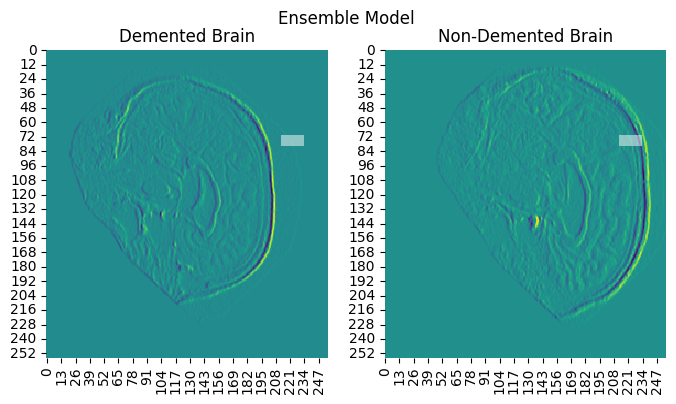

In [ ]:
plot_model('Ensemble Model', folds[4].models[5], X[test_k[0]], Y[test_k[0]])

In [ ]:
# From https://www.geeksforgeeks.org/types-of-convolution-kernels/
identity_kernel = np.array([[0, 0, 0],
                              [0, 1, 0],
                              [0, 0, 0]])
scharr_horizontal_kernel = np.array([[3, 0, -3],
                              [10, 0, 10],
                              [3, 0, -3]])
scharr_vertical_kernel = np.array([[3, 10, 3],
                              [0, 0, 0],
                              [-3, -10, -3]])
laplacian_kernel = np.array([[0, -1, 0],
                              [-1, 4, -1],
                              [0, -1, 0]])

In [ ]:
folds2 = []
for i in range(5):
    # TODO: Include 3d in the model to determine best slice to use
    p_list = [[24,24],[24,12],[48,48]]
    lam = [2**i for i in range(-2,0)]
    params = {
        'p': [[48,48]],
        'lama': 1,
        'lamb': 0.5,
        'lamz': 0,
        'g': Logit(),
        'R': [1,2,3],
        'max_iter': 20,
        'K': K
    }
    ensemble_model = EnsembleCSKPD()
    ensemble_model.fit(X[train_k[i]], Y[train_k[i]], Z=Z[train_k[i]], model_parameters=[
        {'L': convolution(extract_slice_kernel, {'slice': 'sag', 'kernel': identity_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'sag', 'kernel': scharr_horizontal_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'sag', 'kernel': scharr_vertical_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'sag', 'kernel': laplacian_kernel})},
        ], common_parameters=params)
    folds2.append(ensemble_model)

In [ ]:
auc_score2 = {}
for i, f in enumerate(folds2):
    for j, e in enumerate(f.models):
        try:
            auc_score2[(i,j)] = auc(np.round(e.predict(X[test_k[i]],Z=Z[test_k[i]]),0), Y[test_k[i]])
        except:
            pass
display(auc_score2)

{(0, 0): 0.6444444444444445,
 (0, 1): 0.6666666666666666,
 (0, 2): 0.6666666666666666,
 (0, 3): 0.6882352941176472,
 (1, 0): 0.8953488372093023,
 (1, 1): 0.7155844155844157,
 (1, 2): 0.7155844155844157,
 (1, 3): 0.7663865546218487,
 (2, 0): 0.8511904761904762,
 (2, 1): 0.8554216867469879,
 (2, 2): 0.717391304347826,
 (2, 3): 0.6474471830985916,
 (3, 0): 0.7175632911392404,
 (3, 1): 0.7753623188405796,
 (3, 2): 0.7266112266112266,
 (3, 3): 0.6896284829721362,
 (4, 0): 0.9047619047619048,
 (4, 1): 0.7321428571428571,
 (4, 2): 0.8238045738045737,
 (4, 3): 0.7927215189873418}

In [ ]:
for k in range(4):
    score = np.array([s for (i,j), s in auc_score2.items() if j == k])
    print(f"Model {k}: Average ({np.average(score)}), Best ({np.max(score)})")

Model 0: Average (0.8026617907490736), Best (0.9047619047619048)
Model 1: Average (0.7490355889963014), Best (0.8554216867469879)
Model 2: Average (0.7300116374029416), Best (0.8238045738045737)
Model 3: Average (0.7168838067595131), Best (0.7927215189873418)


In [ ]:
folds[0].models

[CSKPD(K=<convolution.convolution object at 0x000001E4D3315B70>,
       L=<convolution.convolution object at 0x000001E4C18DF8B0>, R=3,
       g=<statsmodels.genmod.families.links.Logit object at 0x000001E4C18DFB80>,
       lama=1, lamb=0.5, lamz=0, p=[48, 48]),
 CSKPD(K=<convolution.convolution object at 0x000001E4D3315B70>,
       L=<convolution.convolution object at 0x000001E4C18DEE30>, R=3,
       g=<statsmodels.genmod.families.links.Logit object at 0x000001E4C18DFB80>,
       lama=1, lamb=0.5, lamz=0, p=[48, 48]),
 CSKPD(K=<convolution.convolution object at 0x000001E4D3315B70>,
       L=<convolution.convolution object at 0x000001E4C18DD540>, R=3,
       g=<statsmodels.genmod.families.links.Logit object at 0x000001E4C18DFB80>,
       lama=1, lamb=0.5, lamz=0, p=[48, 48]),
 CSKPD(K=<convolution.convolution object at 0x000001E4D3315B70>,
       L=<convolution.convolution object at 0x000001E4C18DF5B0>, R=3,
       g=<statsmodels.genmod.families.links.Logit object at 0x000001E4C18DFB80>

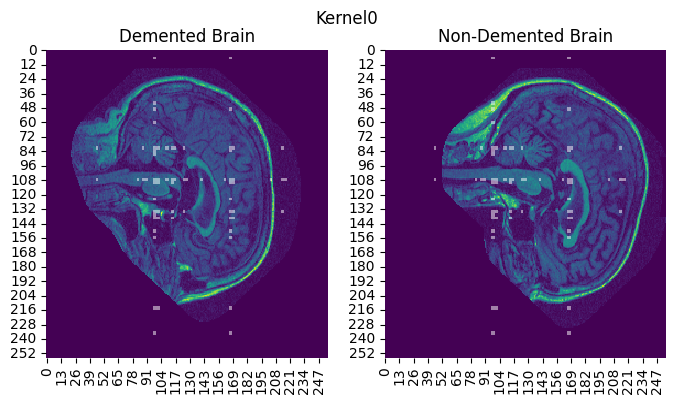

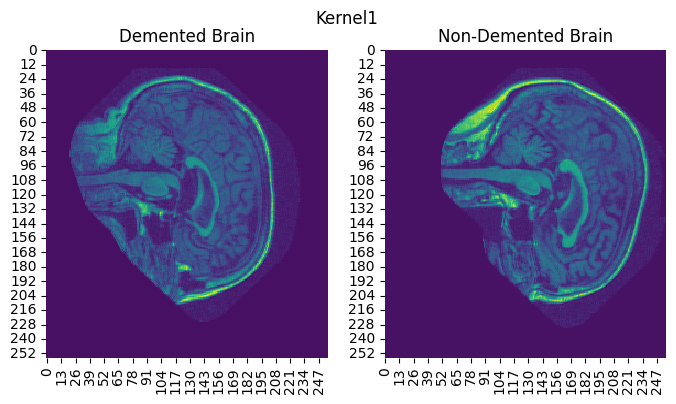

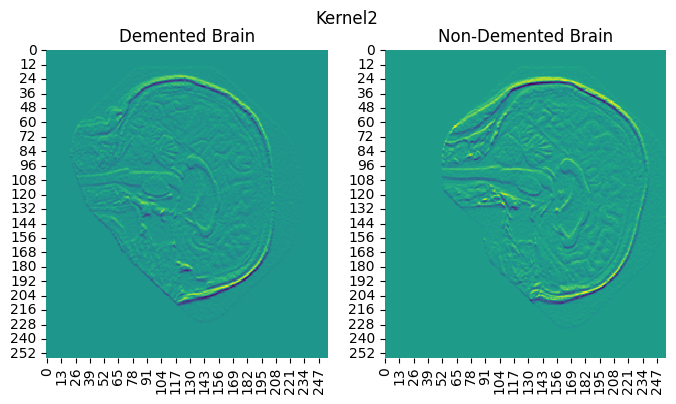

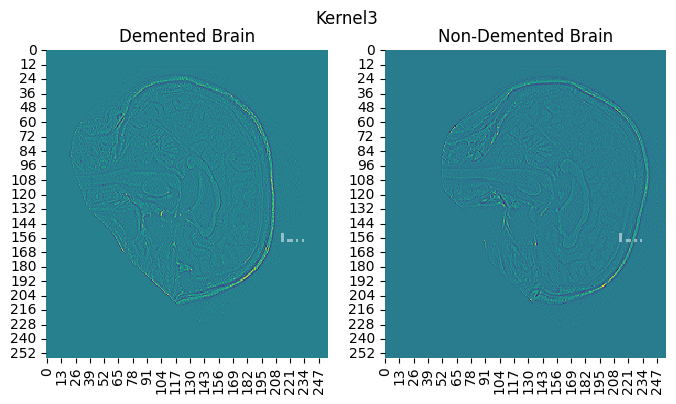

In [ ]:
for i, m in enumerate(folds2[0].models):
    plot_model(f'Kernel{i}', m, X[test_k[0]], Y[test_k[0]], cutoff_point=1E-3)

In [ ]:
def plot_model_single(model_results, X, y, cutoff_point=1E-9, pcs=None):
    # X = model_results.L.convolve(X)
    cmap = plt.cm.gray
    cmap = cmap(np.arange(cmap.N))
    cmap[0, -1] = 0 # first color transparency
    cmap[1:, -1] = 0.5 # alpha value
    custom_cmap = mcolors.ListedColormap(cmap)
    C_hat = model_results.K.deconvolve(model_results.C)
    u, s, v = np.linalg.svd(C_hat)
    if pcs is not None:
        C_hat = u[:,(pcs-1):pcs] @ np.diag(s[(pcs-1):pcs]) @ v[(pcs-1):pcs, :]

    plt.figure(figsize= (4,4))
    fig = plt.subplot(1,1,1)
    # Demented Brain
    plt.subplot(1, 1, 1)
    sns.heatmap(model_results.L.convolve(X[np.argmin(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    fig.set_xticks([])
    fig.set_yticks([])

    plt.show()

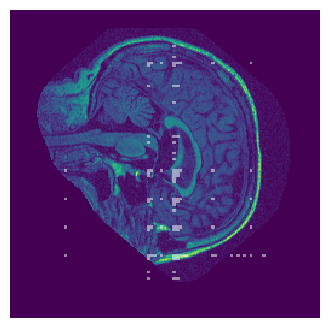

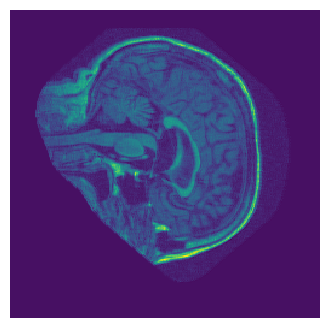

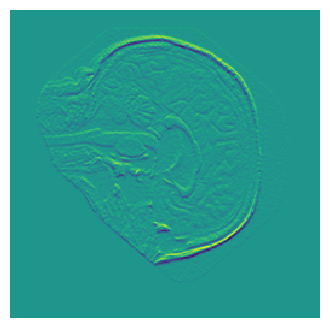

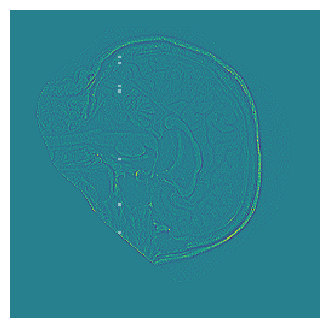

In [ ]:
for i, m in enumerate(folds2[0].models):
    plot_model_single(m, X[test_k[0]], Y[test_k[0]], cutoff_point=1E-3)

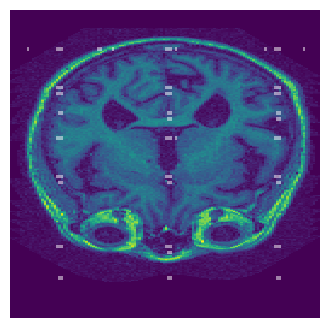

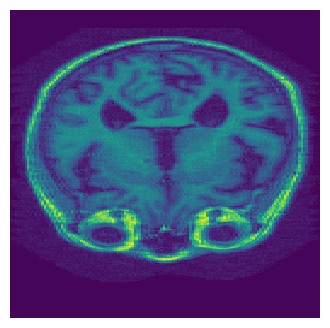

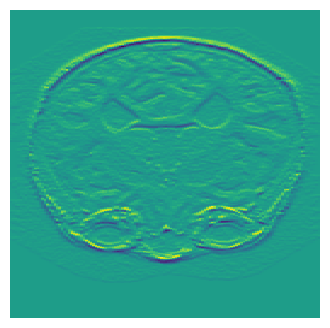

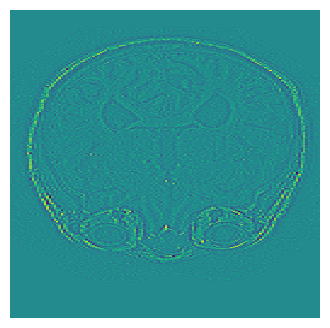

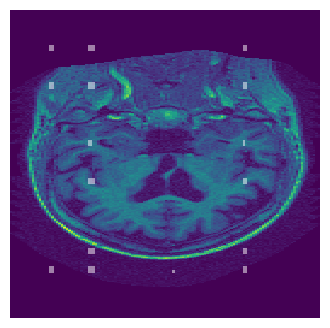

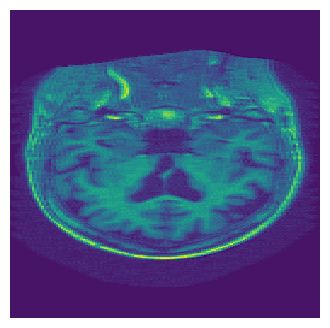

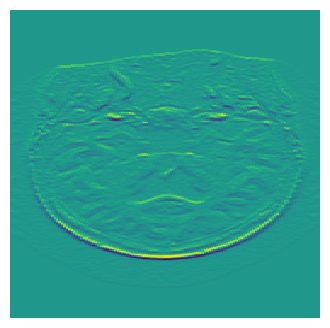

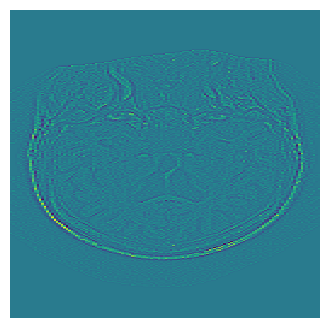

In [ ]:
folds3 = []
for i in range(5):
    # TODO: Include 3d in the model to determine best slice to use
    p_list = [[24,24],[24,12],[48,48]]
    lam = [2**i for i in range(-2,0)]
    params = {
        'p': [[48,48]],
        'lama': 1,
        'lamb': 0.5,
        'lamz': 0,
        'g': Logit(),
        'R': 3,
        'max_iter': 5,
        'K': K
    }
    ensemble_model = EnsembleCSKPD()
    ensemble_model.fit(X[train_k[i]], Y[train_k[i]], Z=Z[train_k[i]], model_parameters=[
        {'L': convolution(extract_slice_kernel, {'slice': 'cor', 'kernel': identity_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'cor', 'kernel': scharr_horizontal_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'cor', 'kernel': scharr_vertical_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'cor', 'kernel': laplacian_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'tra', 'kernel': identity_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'tra', 'kernel': scharr_horizontal_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'tra', 'kernel': scharr_vertical_kernel})},
        {'L': convolution(extract_slice_kernel, {'slice': 'tra', 'kernel': laplacian_kernel})},
        ], common_parameters=params)
    folds3.append(ensemble_model)
for i, m in enumerate(folds3[0].models):
    plot_model_single(m, X[test_k[0]], Y[test_k[0]], cutoff_point=1E-3)